In [2]:
import matplotlib.pyplot as plt


In [6]:
import pandas as pd
w_prefetch_df = pd.read_csv('with_prefetch.csv', header=None, names=['time'])
wt_prefetch_df = pd.read_csv('without_prefetch.csv', header=None, names=['time'])

In [3]:
pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 11.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 11.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 11.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
print(w_prefetch_df.head())
print(w_prefetch_df.describe())

     time
0  0.0474
1  0.0496
2  0.0400
3  0.0470
4  0.0522
              time
count  1000.000000
mean      0.047207
std       0.007698
min       0.018700
25%       0.042000
50%       0.047000
75%       0.051900
max       0.079500


In [8]:
print(w_prefetch_df.dtypes)

time    float64
dtype: object


In [9]:
w_prefetch_df.shape

(1000, 1)

Text(0, 0.5, 'Time (seconds)')

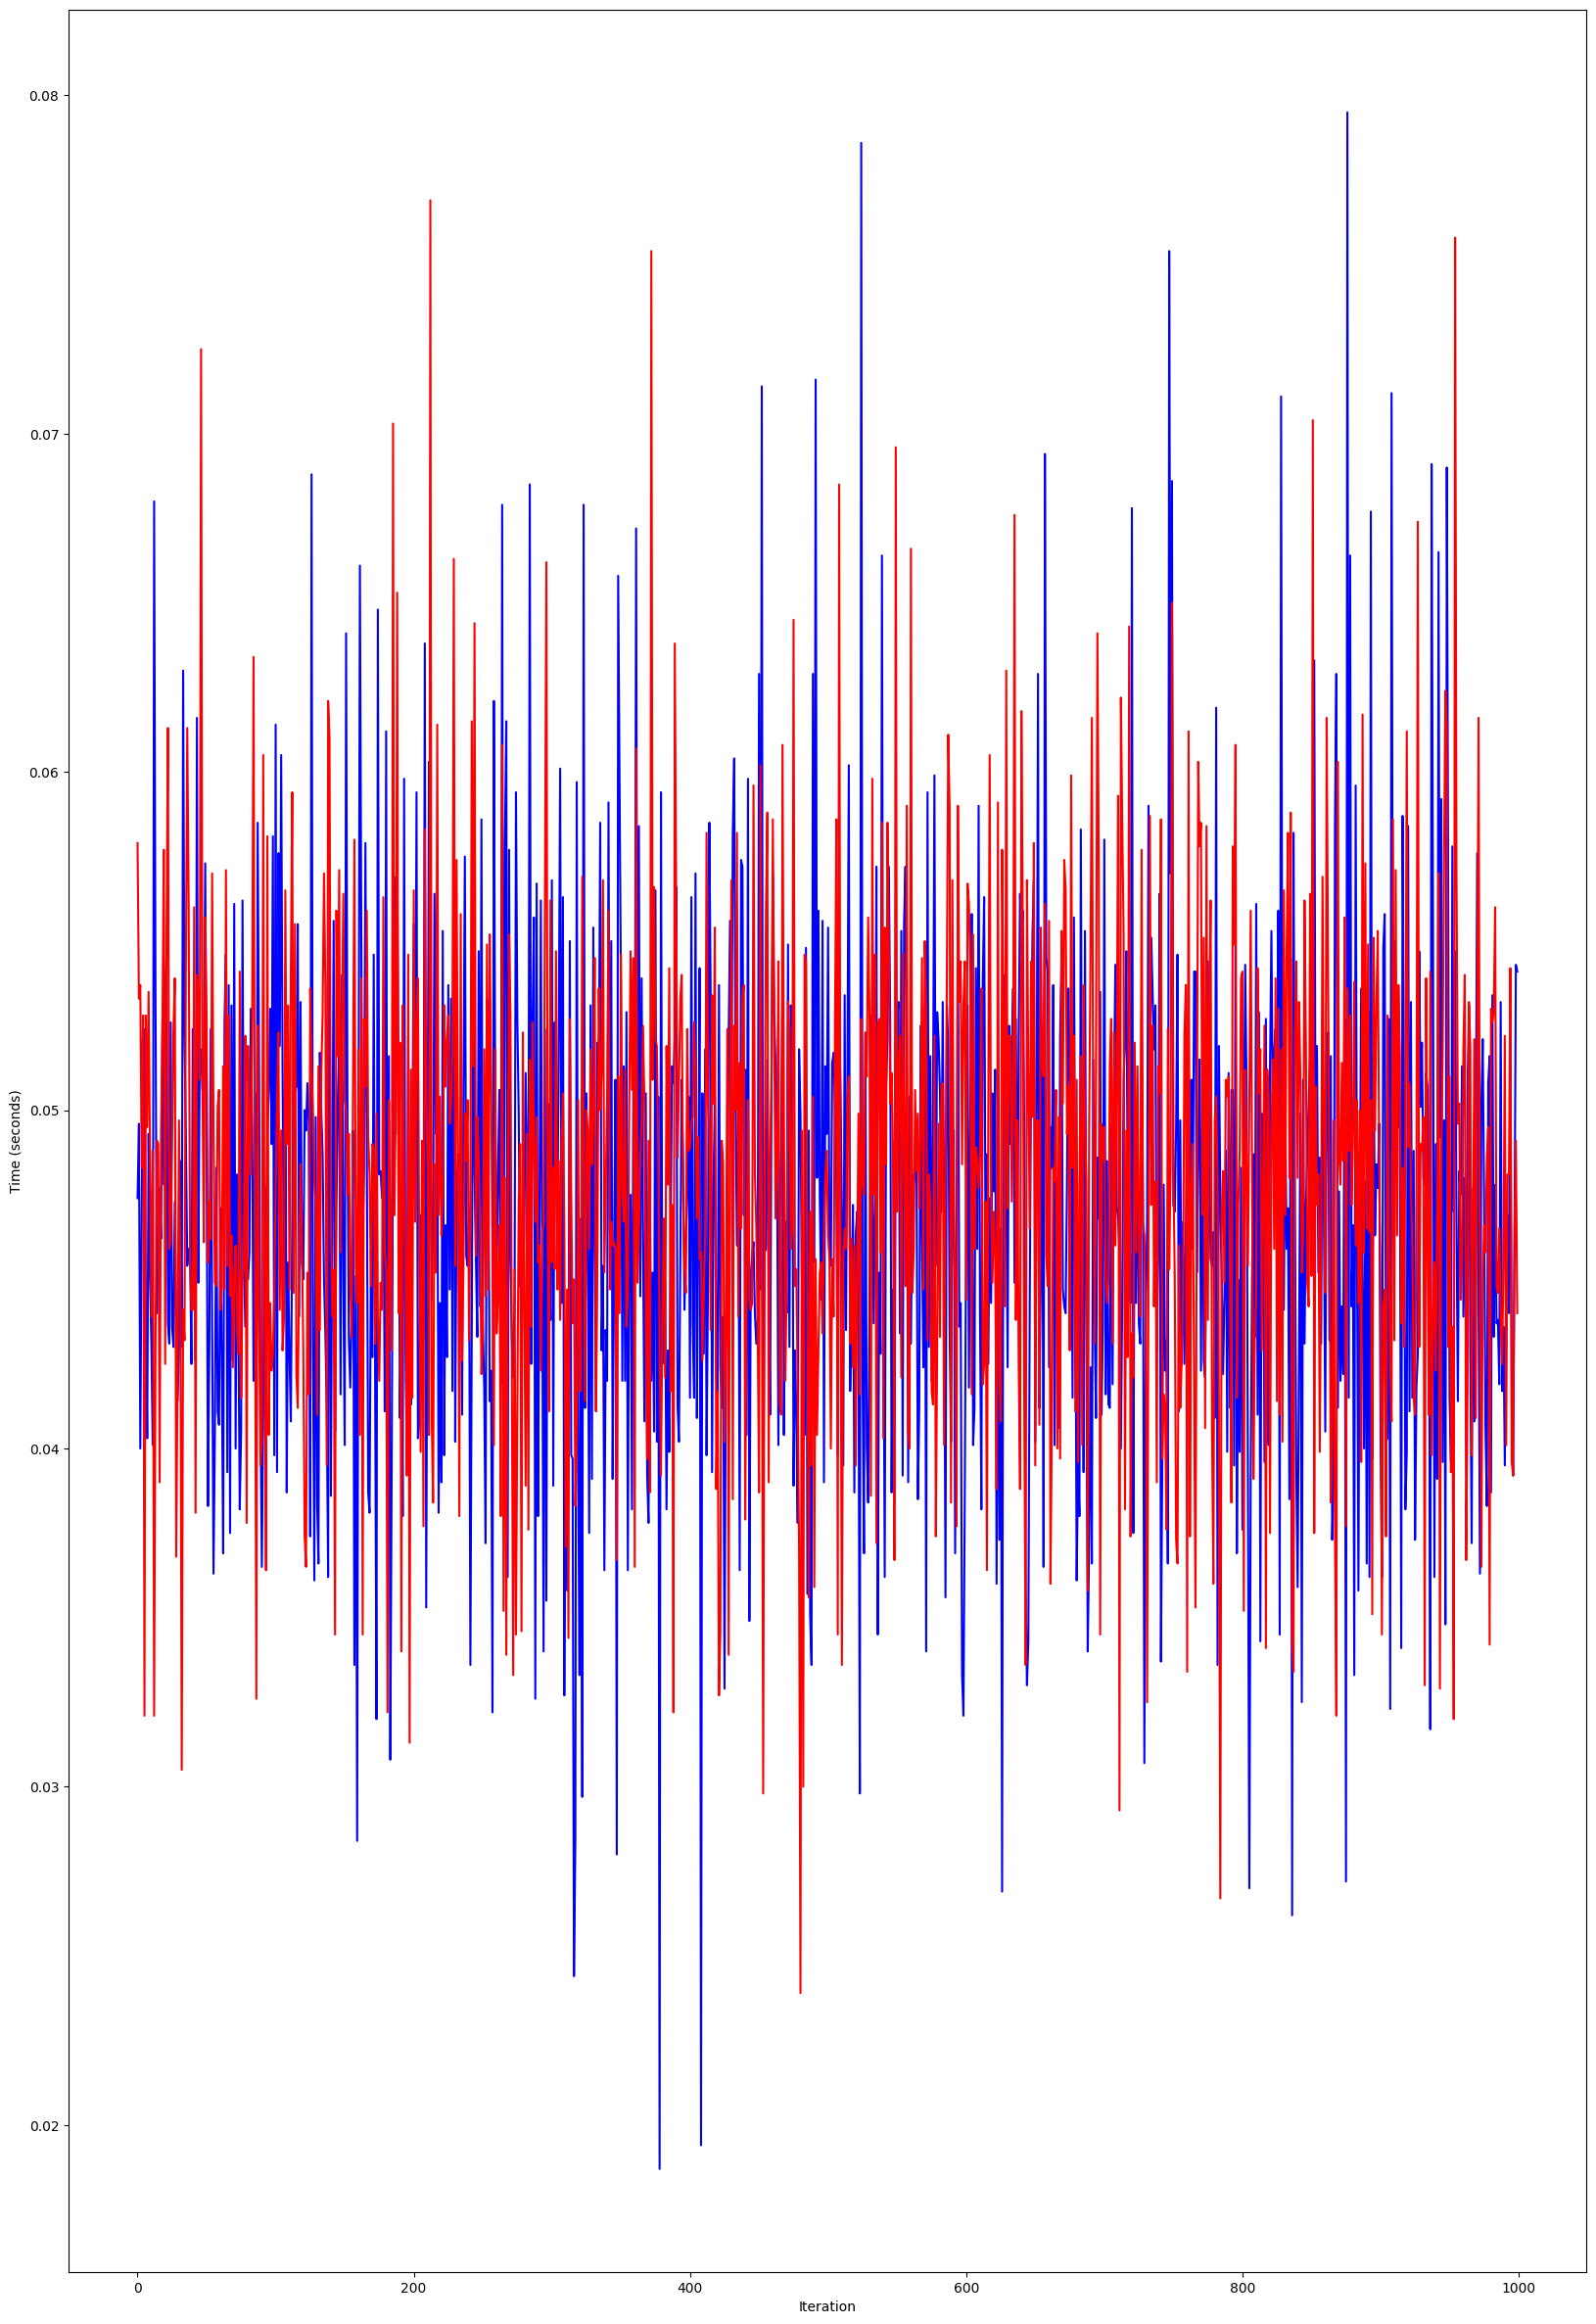

In [16]:
plt.figure(figsize=(20, 30))
plt.plot(w_prefetch_df.index, w_prefetch_df['time'], color='blue', label='With Prefetching')
plt.plot(wt_prefetch_df.index, wt_prefetch_df['time'], color='red', label='Without Prefetching')

plt.xlabel('Iteration')
plt.ylabel('Time (seconds)')

In [26]:
w_pf_df_1 = pd.read_csv('with_prefetch_1_1.csv', header=None, names=['time'])
wt_pf_df_1 = pd.read_csv('without_prefetch_2_1.csv', header=None, names=['time'])

w_pf_df_1.index = range(1, len(w_pf_df_1) + 1)
wt_pf_df_1.index = range(1, len(wt_pf_df_1) + 1)

In [28]:
import numpy as np
custom_ticks = np.arange(1, 1001, 50)  


(array([0.002 , 0.0022, 0.0024, 0.0026, 0.0028, 0.003 , 0.0032, 0.0034,
        0.0036, 0.0038]),
 [Text(0, 0.002, '0.0020'),
  Text(0, 0.0022, '0.0022'),
  Text(0, 0.0024000000000000002, '0.0024'),
  Text(0, 0.0026, '0.0026'),
  Text(0, 0.0028, '0.0028'),
  Text(0, 0.003, '0.0030'),
  Text(0, 0.0032, '0.0032'),
  Text(0, 0.0034000000000000002, '0.0034'),
  Text(0, 0.0036, '0.0036'),
  Text(0, 0.0038000000000000004, '0.0038')])

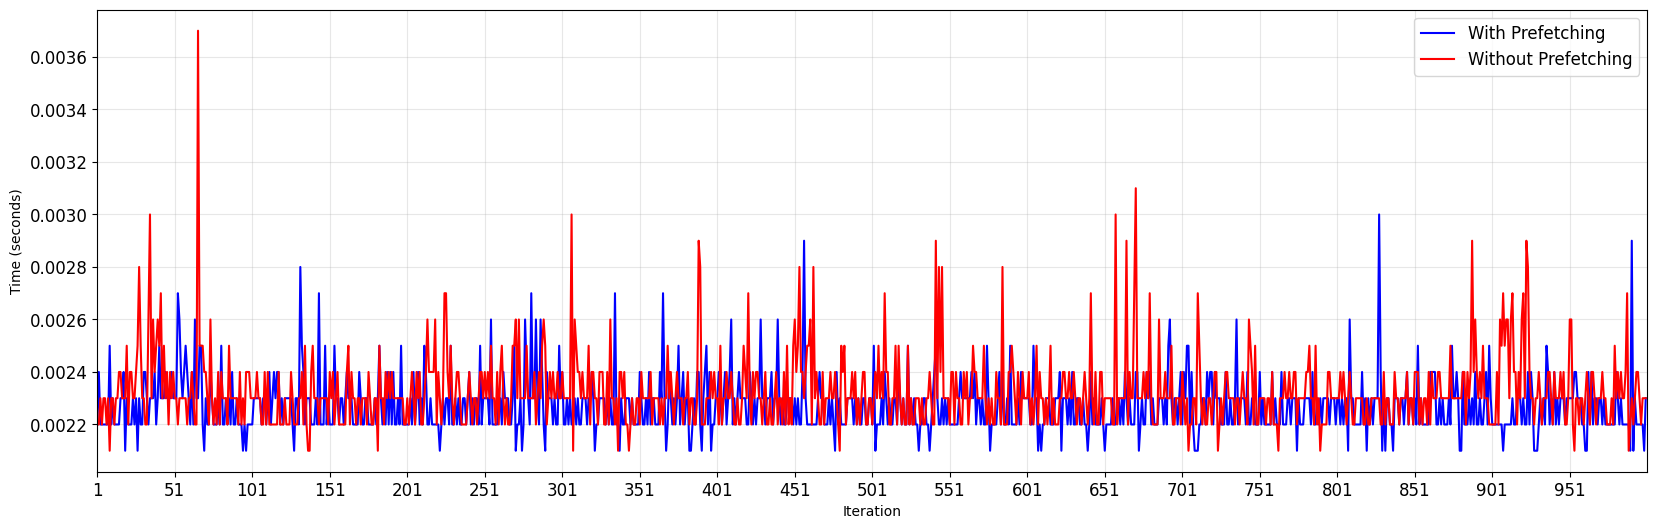

In [30]:
plt.figure(figsize=(20, 6))
plt.plot(w_pf_df_1.index, w_pf_df_1['time'], color='blue', label='With Prefetching')
plt.plot(wt_pf_df_1.index, wt_pf_df_1['time'], color='red', label='Without Prefetching')

plt.xlabel('Iteration')
plt.ylabel('Time (seconds)')

# Set axis limits (adjust these values based on your data)
plt.xlim(1, len(w_pf_df_1)+1)  # Full range of iterations
# plt.ylim(0, max(w_pf_df_1['time'].max(), wt_pf_df_1['time'].max()) * 1.1)  # 10% padding

# Add grid and legend
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Adjust ticks
plt.xticks(custom_ticks, fontsize=12)
plt.yticks(fontsize=12)

# Format y-axis for better precision display
# plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.6f'))

In [31]:
speedup_df = pd.DataFrame()
speedup_df['speedup'] = wt_pf_df_1['time'].div(w_pf_df_1['time'])

In [32]:
speedup_df.index = range(1, len(speedup_df) + 1)

In [33]:
speedup_df.head()

,speedup
1,1.000000
2,0.916667
3,1.045455
4,1.000000
5,1.045455


(1.0, 1000.0)

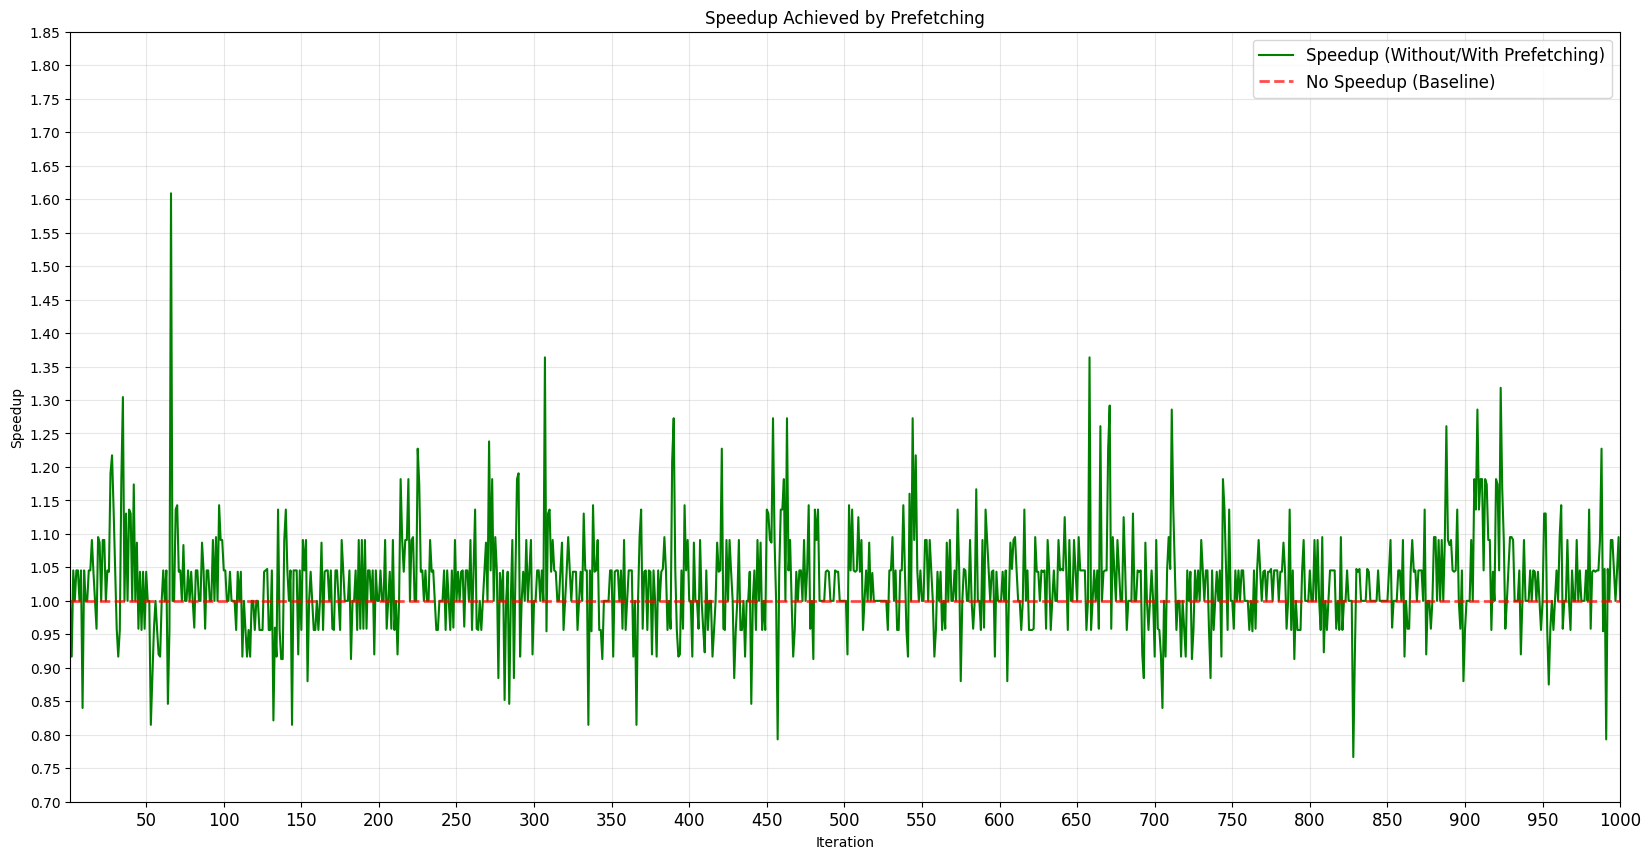

In [76]:
plt.figure(figsize=(20, 10))
plt.plot(speedup_df.index, speedup_df['speedup'], color='green', label='Speedup (Without/With Prefetching)')

plt.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='No Speedup (Baseline)')

plt.xlabel('Iteration')
plt.ylabel('Speedup')
plt.title('Speedup Achieved by Prefetching')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
custom_ticks = np.arange(0, 1001, 50)  

plt.xticks(custom_ticks, fontsize=12)
plt.yticks(np.arange(0.7, 1.9, 0.05))
plt.xlim(1, custom_ticks.max())  # 10% padding
# plt.ylim(0, speedup_df['speedup'].max() * 1.1)  # 10% padding

In [78]:
hw_on = pd.DataFrame()
hw_on['time_without_prefetch'] = pd.read_csv('without_prefetch_hp_on.csv', header=None)
hw_on['time_with_prefetch'] = pd.read_csv('with_prefetch_hp_on.csv', header=None)
hw_on['time_without_prefetch'].describe()


count    1000.000000
mean        0.048552
std         0.007218
min         0.026300
25%         0.043600
50%         0.048600
75%         0.053000
max         0.088600
Name: time_without_prefetch, dtype: float64

In [79]:
hw_on['time_with_prefetch'].describe()

count    1000.000000
mean        0.047559
std         0.007764
min         0.013700
25%         0.042700
50%         0.047300
75%         0.051900
max         0.077800
Name: time_with_prefetch, dtype: float64

In [81]:
speedup_hw_on  = 0.048552/0.047559
speedup_hw_on

1.0208793288336593

In [82]:
hw_off = pd.DataFrame()
hw_off['time_without_prefetch'] = pd.read_csv('without_prefetch_hp_off.csv', header=None)
hw_off['time_with_prefetch'] = pd.read_csv('with_prefetch_hp_off.csv', header=None)
hw_off['time_without_prefetch'].describe()


count    1000.000000
mean        0.048279
std         0.007072
min         0.025000
25%         0.043700
50%         0.048300
75%         0.053100
max         0.083900
Name: time_without_prefetch, dtype: float64

In [83]:
hw_off['time_with_prefetch'].describe()

count    1000.000000
mean        0.047834
std         0.007694
min         0.012800
25%         0.042875
50%         0.047700
75%         0.052700
max         0.089600
Name: time_with_prefetch, dtype: float64

In [84]:
speedup_hw_off = 0.048279/0.047834
speedup_hw_off

1.0093030062298785

In [85]:
speedup_hw_on - speedup_hw_off

0.011576322603780831

([0, 1],
 [Text(0, 0, 'With HW Prefetching ON'),
  Text(1, 0, 'Without HW Prefetching OFF')])

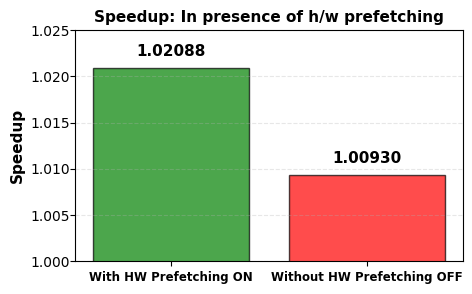

In [132]:
import matplotlib.pyplot as plt
import numpy as np

# Your data
labels = ['With HW Prefetching ON', 'Without HW Prefetching OFF']
values = [1.02088, 1.00930]

# Create the bar plot
plt.figure(figsize=(5, 3))
bars = plt.bar(labels, values, color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.015)

# Add value labels on top of each bar
for i, v in enumerate(values):
    plt.text(i, v + 0.001, f'{v:.5f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Customize the plot
plt.ylabel('Speedup', fontsize=11, fontweight='bold')
plt.title('Speedup: In presence of h/w prefetching', fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add a horizontal line at y=1 for reference
# plt.axhline(y=1, color='blue', linestyle='--', alpha=0.7, label='Baseline (1.0)')

# Adjust y-axis limits to better show the differences
# plt.ylim(1, max(values) * 1.0120)
plt.ylim(1, 1.025)
plt.tick_params(axis='y', which='major', pad=0.1)

# Rotate x-axis labels if needed
# plt.xticks(rotation=0, ha='right')
plt.xticks(fontsize=8.5, fontweight='bold')

# Add legend


# # Show the plot
# plt.tight_layout()
# plt.show()

In [3]:
!pip install pandas numpy matplotlib

  Using cached pandas-2.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (91 kB)
  Using cached numpy-2.3.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached matplotlib-3.10.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.59.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (108 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-11.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.0 kB)
  Using cache

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('with_prefetch_1_1.csv', header=None, names=['time'])



(array([[<Axes: title={'center': 'time'}>]], dtype=object),
               time
 count  1000.000000
 mean      0.002271
 std       0.000105
 min       0.002100
 25%       0.002200
 50%       0.002300
 75%       0.002300
 max       0.003000)

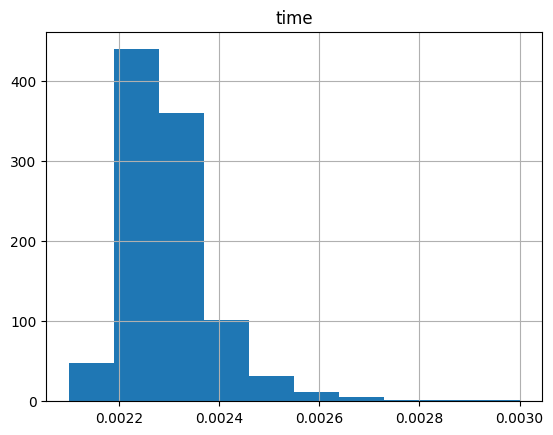

In [9]:
df.hist() , df.describe()

In [3]:
!pip install pandas matplotlib numpy

  Using cached pandas-2.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (91 kB)
  Using cached matplotlib-3.10.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached numpy-2.3.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.59.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (108 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-11.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.0 kB)
  Using cache

In [15]:
import pandas as pd

In [29]:
without_prefetch_10r_df = pd.DataFrame()
without_prefetch_100r_df = pd.DataFrame()
without_prefetch_1000r_df = pd.DataFrame()
without_prefetch_10000r_df = pd.DataFrame()

without_prefetch_10r_df = pd.read_csv('without_prefetch_10r.csv', header=None, names=['10r'])
without_prefetch_100r_df = pd.read_csv('without_prefetch_100r.csv', header=None, names=['100r'])
without_prefetch_1000r_df = pd.read_csv('without_prefetch_1000r.csv', header=None, names=['1000r'])
without_prefetch_10000r_df = pd.read_csv('without_prefetch_10000r.csv', header=None, names=['10000r'])

<Axes: >

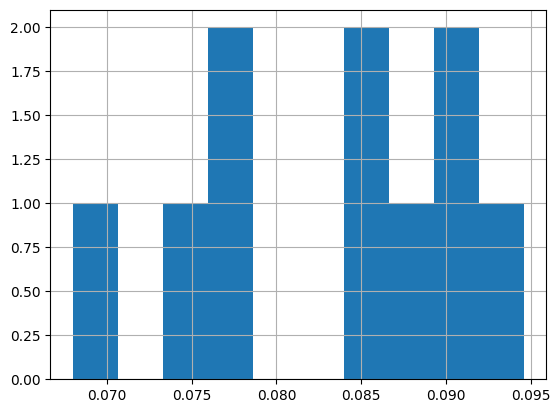

In [30]:
without_prefetch_10r_df['10r'].hist()

In [31]:
without_prefetch_10r_df['10r'].describe()

count    10.000000
mean      0.083510
std       0.008617
min       0.068000
25%       0.077575
50%       0.085250
75%       0.090650
max       0.094600
Name: 10r, dtype: float64

<Axes: >

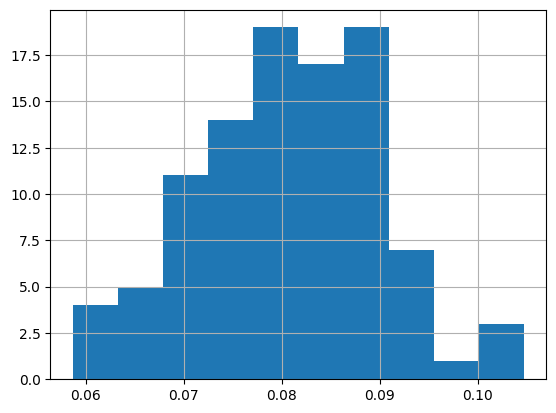

In [42]:
without_prefetch_100r_df['100r'].hist()

In [33]:
without_prefetch_100r_df['100r'].describe()

count    100.000000
mean       0.080689
std        0.009371
min        0.058700
25%        0.073625
50%        0.081050
75%        0.087350
max        0.104700
Name: 100r, dtype: float64

In [44]:
without_prefetch_100r_df['100r'].median(),without_prefetch_100r_df['100r'].mean()

(np.float64(0.08105), np.float64(0.08068900000000001))

<Axes: >

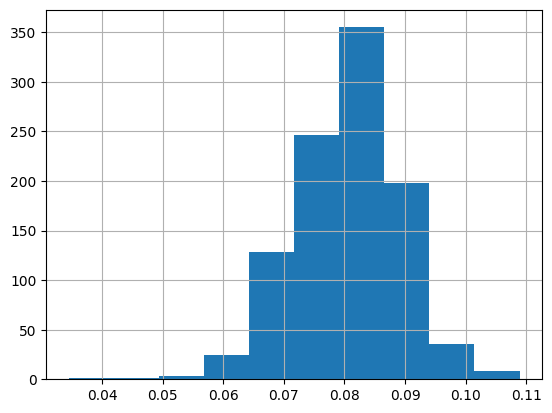

In [34]:
without_prefetch_1000r_df['1000r'].hist()

In [35]:
without_prefetch_1000r_df['1000r'].describe()

count    1000.000000
mean        0.080598
std         0.008660
min         0.034500
25%         0.075450
50%         0.080950
75%         0.086300
max         0.108900
Name: 1000r, dtype: float64

<Axes: >

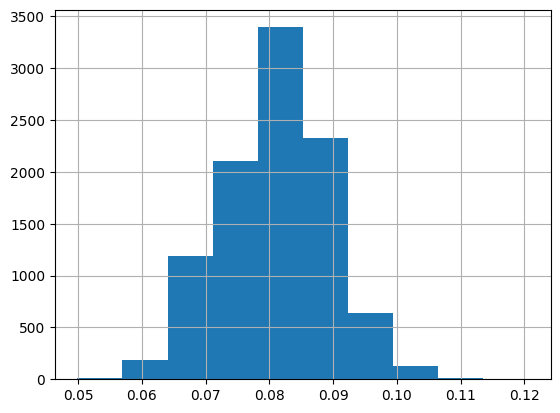

In [36]:
without_prefetch_10000r_df['10000r'].hist()

In [38]:
without_prefetch_10000r_df['10000r'].describe()

count    10000.000000
mean         0.080977
std          0.008406
min          0.049900
25%          0.075800
50%          0.081100
75%          0.086800
max          0.120600
Name: 10000r, dtype: float64